In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/setup_env.sh"
#!/bin/bash
set -e

echo "===== SETUP MANGA-TEXT-SEGMENTATION ENV ====="

DRIVE_DATA_ROOT="/content/drive/MyDrive/Colab Notebooks/data"
REPO_DIR="/content/Manga-Text-Segmentation"
VENV_DIR="/content/env38"

# --- 1. Cài Python 3.8 ---
if [ ! -x "/usr/bin/python3.8" ]; then
    echo ">> Cài Python 3.8..."
    apt-get update -y -qq
    apt-get install -y -qq python3.8 python3.8-venv python3.8-dev
else
    echo ">> Python 3.8 đã có sẵn, bỏ qua."
fi

# --- 2. Tạo venv + cài package ---
if [ ! -f "$VENV_DIR/bin/python" ]; then
    echo ">> Tạo venv..."
    python3.8 -m venv "$VENV_DIR"
    "$VENV_DIR/bin/pip" install --upgrade pip -q
    echo ">> Cài fastai (no-deps để né spacy)..."
    "$VENV_DIR/bin/pip" install --no-deps fastai==1.0.60 -q
    echo ">> Cài các package vision cần thiết..."
    "$VENV_DIR/bin/pip" install --only-binary=:all: -q \
        torch==1.4.0 torchvision==0.5.0 \
        numpy==1.24.4 pandas==2.0.3 Pillow==10.4.0 \
        matplotlib==3.7.5 scipy==1.10.1 requests==2.32.4 \
        pyyaml==6.0.3 packaging beautifulsoup4 bottleneck \
        fastprogress numexpr
    echo ">> Cài scikit-image bản tương thích (có watershed trong morphology)..."
    "$VENV_DIR/bin/pip" install --only-binary=:all: -q scikit-image==0.17.2
else
    echo ">> venv đã tồn tại, bỏ qua cài đặt."
fi

# --- 3. Clone repo ---
if [ ! -d "$REPO_DIR" ]; then
    echo ">> Clone repo Manga-Text-Segmentation..."
    git clone -q https://github.com/juvian/Manga-Text-Segmentation.git "$REPO_DIR"
else
    echo ">> Repo đã tồn tại, bỏ qua clone."
fi

# --- 4. Tải checkpoint ---
if [ ! -f "$REPO_DIR/model.pkl" ]; then
    echo ">> Tải checkpoint model.pkl (~328MB)..."
    wget -q -O "$REPO_DIR/model.pkl" \
        https://github.com/juvian/Manga-Text-Segmentation/releases/download/v1.0/fold.0.-.final.refined.model.2.pkl
else
    echo ">> model.pkl đã có, bỏ qua tải."
fi

# --- 5. Giải nén dataset từ Drive ---
if [ ! -d "/content/data/raw/Manga109s_released_2026_05_21" ]; then
    echo ">> Giải nén raw images..."
    mkdir -p /content/data/raw
    unzip -q "$DRIVE_DATA_ROOT/raw/Manga109s_released_2026_05_21.zip" -d /content/data/raw
else
    echo ">> Raw images đã giải nén, bỏ qua."
fi

if [ ! -d "/content/data/groundtruth/post-processed" ]; then
    echo ">> Giải nén groundtruth..."
    mkdir -p /content/data/groundtruth
    unzip -q "$DRIVE_DATA_ROOT/groundtruth/post-processed.zip" -d /content/data/groundtruth
else
    echo ">> Groundtruth đã giải nén, bỏ qua."
fi

echo "===== SETUP HOÀN TẤT ====="
echo "Test nhanh: !$VENV_DIR/bin/python -c \"import torch, fastai; print(torch.__version__, fastai.__version__)\""

Writing /content/drive/MyDrive/Colab Notebooks/setup_env.sh


In [3]:
!bash "/content/drive/MyDrive/Colab Notebooks/setup_env.sh"

===== SETUP MANGA-TEXT-SEGMENTATION ENV =====
>> Cài Python 3.8...
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libpython3.8-minimal:amd64.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../00-libpython3.8-minimal_3.8.20-1+noble1_amd64.deb ...
Unpacking libpython3.8-minimal:amd64 (3.8.20-1+noble1) ...
Selecting previously unselected package python3.8-minimal.
Preparing to unpack .../01-python3.8-minimal_3.8.20-1+noble1_amd64.deb ...
Unpacking python3.8-minimal (3.8.20-1+noble1) ...
Selecting previously unselected package libnsl2:amd64.
Preparing to un

In [8]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/test_predict_iou.py"
import argparse
import numpy as np
if not hasattr(np, 'bool'): np.bool = bool
if not hasattr(np, 'int'): np.int = int
if not hasattr(np, 'float'): np.float = float
if not hasattr(np, 'object'): np.object = object

import sys
sys.path.insert(0, '/content/Manga-Text-Segmentation')
sys.path.insert(0, '/content/Manga-Text-Segmentation/code')

from fastai.vision import *
import torch
from PIL import Image
import matplotlib
matplotlib.use('Agg')  # không cần display trực tiếp, chỉ lưu file
import matplotlib.pyplot as plt

RAW_ROOT = '/content/data/raw/Manga109s_released_2026_05_21/images'
GT_ROOT = '/content/data/groundtruth/post-processed'
MODEL_PATH = '/content/Manga-Text-Segmentation'
OUT_DIR = '/content/output_viz'

def load_model():
    print(">> Đang load model...")
    learn = load_learner(Path(MODEL_PATH), 'model.pkl')
    print(">> Load model xong.")
    return learn

def predict_one(learn, manga, page):
    img_path = f'{RAW_ROOT}/{manga}/{page}.jpg'
    gt_path = f'{GT_ROOT}/{manga}/{page}.png'

    img = open_image(img_path)
    pred_class, pred_idx, outputs = learn.predict(img)
    prob = torch.sigmoid(outputs)
    pred_mask = (prob > 0.5).squeeze().numpy().astype(bool)

    gt_rgb = np.array(Image.open(gt_path).convert('RGB'))
    is_white = np.all(gt_rgb == 255, axis=-1)
    gt_mask_full = ~is_white

    h, w = pred_mask.shape
    gt_mask = gt_mask_full[:h, :w]

    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    iou = intersection / union if union > 0 else 0

    tp = intersection
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    metrics = {'iou': iou, 'precision': precision, 'recall': recall, 'f1': f1}

    raw_img = np.array(Image.open(img_path).convert('RGB'))

    return raw_img, gt_mask, pred_mask, metrics

def visualize(raw_img, gt_mask, pred_mask, metrics, manga, page):
    os.makedirs(OUT_DIR, exist_ok=True)

    overlay = raw_img.copy()
    overlay[pred_mask & ~gt_mask] = [255, 0, 0]      # đỏ: model đoán nhầm (FP)
    overlay[~pred_mask & gt_mask] = [0, 0, 255]      # xanh dương: model bỏ sót (FN)
    overlay[pred_mask & gt_mask] = [0, 255, 0]       # xanh lá: model đoán đúng (TP)

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(raw_img); axes[0].set_title("Ảnh gốc"); axes[0].axis('off')
    axes[1].imshow(gt_mask, cmap='gray'); axes[1].set_title("Ground Truth"); axes[1].axis('off')
    axes[2].imshow(pred_mask, cmap='gray'); axes[2].set_title("Prediction"); axes[2].axis('off')
    axes[3].imshow(overlay); axes[3].set_title("Overlay (xanh=đúng, đỏ=nhầm, xanh dương=sót)"); axes[3].axis('off')

    fig.suptitle(f"{manga}/{page} — IoU: {metrics['iou']:.4f} | Precision: {metrics['precision']:.4f} | "
                 f"Recall: {metrics['recall']:.4f} | F1: {metrics['f1']:.4f}", fontsize=13)

    out_path = f'{OUT_DIR}/{manga}_{page}.png'
    plt.tight_layout()
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.close()
    print(f">> Đã lưu visualization: {out_path}")
    return out_path

if __name__ == '__main__':
    parser = argparse.ArgumentParser()
    parser.add_argument('--manga', required=True, help='Tên manga, ví dụ GarakutayaManta')
    parser.add_argument('--page', required=True, help='Số trang zero-padded, ví dụ 001')
    args = parser.parse_args()

    learn = load_model()
    raw_img, gt_mask, pred_mask, metrics = predict_one(learn, args.manga, args.page)

    print(f"IoU: {metrics['iou']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1: {metrics['f1']:.4f}")

    visualize(raw_img, gt_mask, pred_mask, metrics, args.manga, args.page)

Writing /content/drive/MyDrive/Colab Notebooks/test_predict_iou.py


In [9]:
!/content/env38/bin/python "/content/drive/MyDrive/Colab Notebooks/test_predict_iou.py" --manga GarakutayaManta --page 001

/content/drive/MyDrive/Colab Notebooks/test_predict_iou.py:3: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'): np.bool = bool
/content/drive/MyDrive/Colab Notebooks/test_predict_iou.py:6: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'object'): np.object = object
>> Đang load model...
>> Load model xong.
IoU: 0.8556
Precision: 0.9037
Recall: 0.9414
F1: 0.9222
>> Đã lưu visualization: /content/output_viz/GarakutayaManta_001.png


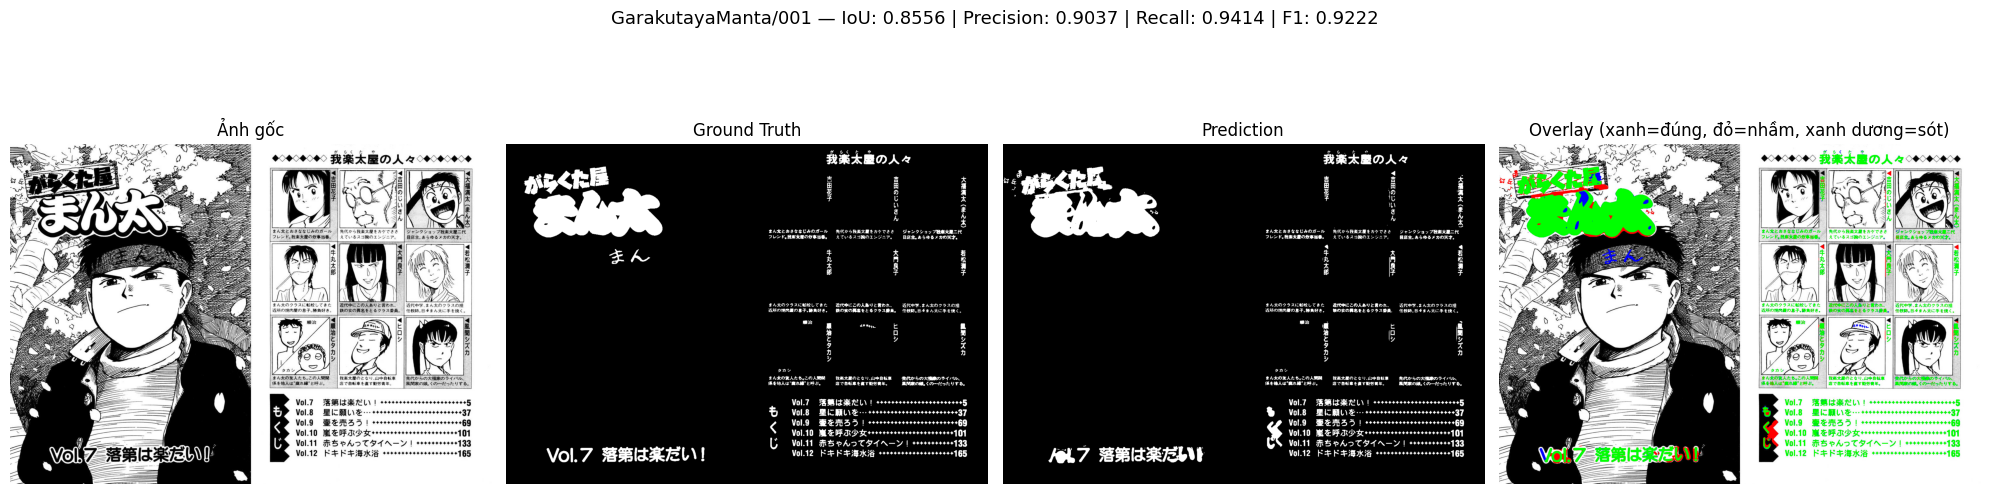

In [10]:
from PIL import Image as PILImage
PILImage.open('/content/output_viz/GarakutayaManta_001.png')

In [14]:
%%writefile "/content/drive/MyDrive/Colab Notebooks/run_benchmark.py"
import argparse
import csv
import json
import os
import subprocess
import time
import traceback

import numpy as np
if not hasattr(np, 'bool'): np.bool = bool
if not hasattr(np, 'int'): np.int = int
if not hasattr(np, 'float'): np.float = float
if not hasattr(np, 'object'): np.object = object

import sys
sys.path.insert(0, '/content/Manga-Text-Segmentation')
sys.path.insert(0, '/content/Manga-Text-Segmentation/code')

from fastai.vision import *
import torch
from PIL import Image
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# ===== Cấu hình =====
RAW_ROOT = '/content/data/raw/Manga109s_released_2026_05_21/images'
GT_ROOT = '/content/data/groundtruth/post-processed'
MODEL_PATH = '/content/Manga-Text-Segmentation'
CHECKPOINT_NAME = 'model.pkl'
MANIFEST_PATH = '/content/drive/MyDrive/Colab Notebooks/manifest.csv'
METHOD_NAME = 'manga-text-segmentation'
DELIVERABLES_ROOT = f'/content/drive/MyDrive/Colab Notebooks/deliverables/{METHOD_NAME}'
MASKS_ROOT = os.path.join(DELIVERABLES_ROOT, 'outputs')
VIZ_ROOT = os.path.join(DELIVERABLES_ROOT, 'visualizations')
THRESHOLD = 0.5
CANONICAL_W, CANONICAL_H = 1654, 1170  # aligned evaluation space theo Spec 001/002
N_VIZ_PER_BUCKET = 2  # số case tốt/trung bình/tệ muốn xuất viz


def get_repo_commit(repo_dir):
    try:
        return subprocess.check_output(
            ['git', '-C', repo_dir, 'rev-parse', 'HEAD'], text=True
        ).strip()
    except Exception:
        return 'unknown'


def load_model():
    print(">> Đang load model...")
    learn = load_learner(Path(MODEL_PATH), CHECKPOINT_NAME)
    print(">> Load model xong.")
    return learn


def align_to_canonical(arr):
    """Pad 0 nếu thiếu, crop top-left nếu thừa, để mọi output đều đúng
    1654x1170 — không phụ thuộc vào kích thước output riêng của model từng trang."""
    h, w = arr.shape[:2]
    pad_h, pad_w = max(0, CANONICAL_H - h), max(0, CANONICAL_W - w)
    if pad_h or pad_w:
        pad_spec = ((0, pad_h), (0, pad_w)) if arr.ndim == 2 else ((0, pad_h), (0, pad_w), (0, 0))
        arr = np.pad(arr, pad_spec, mode='constant', constant_values=0)
    return arr[:CANONICAL_H, :CANONICAL_W]


def predict_one(learn, manga, page):
    """CORE LOGIC — không đổi so với bản gốc, chỉ thêm đo thời gian + alignment cuối."""
    img_path = f'{RAW_ROOT}/{manga}/{page}.jpg'
    gt_path = f'{GT_ROOT}/{manga}/{page}.png'

    orig_w, orig_h = Image.open(img_path).size

    t0 = time.time()
    img = open_image(img_path)
    pred_class, pred_idx, outputs = learn.predict(img)
    prob = torch.sigmoid(outputs)
    pred_mask_raw = (prob > THRESHOLD).squeeze().numpy().astype(bool)
    inference_time = time.time() - t0
    model_raw_h, model_raw_w = pred_mask_raw.shape

    gt_rgb = np.array(Image.open(gt_path).convert('RGB'))
    is_white = np.all(gt_rgb == 255, axis=-1)
    gt_mask_raw = ~is_white

    pred_mask = align_to_canonical(pred_mask_raw)
    gt_mask = align_to_canonical(gt_mask_raw)

    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    iou = intersection / union if union > 0 else 0
    tp = intersection
    fp = np.logical_and(pred_mask, ~gt_mask).sum()
    fn = np.logical_and(~pred_mask, gt_mask).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    metrics = {'iou': float(iou), 'precision': float(precision), 'recall': float(recall), 'f1': float(f1)}

    raw_img = align_to_canonical(np.array(Image.open(img_path).convert('RGB')))

    info = {
        'orig_size': (orig_w, orig_h),
        'model_raw_size': (model_raw_w, model_raw_h),
        'inference_time': inference_time,
    }
    return raw_img, gt_mask, pred_mask, metrics, info


def save_mask_png(pred_mask_bool, out_path):
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    Image.fromarray((pred_mask_bool.astype(np.uint8)) * 255, mode='L').save(out_path)


def build_metadata(image_id, checkpoint_commit, info, status, error=None):
    return {
        "image_id": image_id,
        "method": METHOD_NAME,
        "repository": "https://github.com/juvian/Manga-Text-Segmentation",
        "commit": checkpoint_commit,
        "checkpoint": CHECKPOINT_NAME,
        "checkpoint_strategy": "single-fold-fallback (fold.0 only) — LOFO 5-fold chua implement, xem ghi chu gioi han",
        "input_size": list(info['orig_size']),
        "model_raw_output_size": list(info['model_raw_size']),
        "output_size": [CANONICAL_W, CANONICAL_H],
        "preprocessing": ["ImageNet mean/std normalization (fastai default)", "internal resize/pad theo fastai transform"],
        "postprocessing": [f"sigmoid threshold @ {THRESHOLD}", "pad/crop to canonical 1654x1170"],
        "threshold": THRESHOLD,
        "alignment": "self-derived-manifest (390 pairs, giao ten file raw/gt), canonical crop/pad 1654x1170 theo Spec 001/002",
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "inference_time_seconds": info.get('inference_time', 0.0),
        "status": status,
        "error": error,
    }


def visualize(raw_img, gt_mask, pred_mask, metrics, manga, page):
    """CORE LOGIC vẽ — giữ nguyên bản gốc, chỉ đổi output dir."""
    os.makedirs(VIZ_ROOT, exist_ok=True)
    overlay = raw_img.copy()
    overlay[pred_mask & ~gt_mask] = [255, 0, 0]
    overlay[~pred_mask & gt_mask] = [0, 0, 255]
    overlay[pred_mask & gt_mask] = [0, 255, 0]

    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes[0].imshow(raw_img); axes[0].set_title("Anh goc"); axes[0].axis('off')
    axes[1].imshow(gt_mask, cmap='gray'); axes[1].set_title("Ground Truth"); axes[1].axis('off')
    axes[2].imshow(pred_mask, cmap='gray'); axes[2].set_title("Prediction"); axes[2].axis('off')
    axes[3].imshow(overlay); axes[3].set_title("Overlay (xanh=dung, do=nham, xanh duong=sot)"); axes[3].axis('off')
    fig.suptitle(f"{manga}/{page} - IoU: {metrics['iou']:.4f} | P: {metrics['precision']:.4f} | "
                 f"R: {metrics['recall']:.4f} | F1: {metrics['f1']:.4f}", fontsize=13)

    out_path = f'{VIZ_ROOT}/{manga}_{page}.png'
    plt.tight_layout()
    plt.savefig(out_path, dpi=100, bbox_inches='tight')
    plt.close()
    return out_path


def main():
    os.makedirs(MASKS_ROOT, exist_ok=True)
    os.makedirs(VIZ_ROOT, exist_ok=True)
    commit = get_repo_commit(MODEL_PATH)
    learn = load_model()

    with open(MANIFEST_PATH, newline='', encoding='utf-8') as f:
        pages = [(row['manga'], row['page_id']) for row in csv.DictReader(f)]
    print(f">> Tong so page trong manifest: {len(pages)}")

    per_page_metrics, errors, viz_candidates = [], [], []

    for i, (manga, page) in enumerate(pages, 1):
        image_id = f"{manga}/{page}"
        print(f"[{i}/{len(pages)}] {image_id}", end=' ... ')
        try:
            raw_img, gt_mask, pred_mask, metrics, info = predict_one(learn, manga, page)

            save_mask_png(pred_mask, os.path.join(MASKS_ROOT, manga, f"{page}.png"))
            meta = build_metadata(image_id, commit, info, status="success")
            with open(os.path.join(MASKS_ROOT, manga, f"{page}.json"), "w", encoding="utf-8") as jf:
                json.dump(meta, jf, ensure_ascii=False, indent=2)

            row = {"image_id": image_id, "manga": manga, "page_id": page,
                   **metrics, "inference_time_seconds": info['inference_time']}
            per_page_metrics.append(row)
            viz_candidates.append((metrics['iou'], manga, page, raw_img, gt_mask, pred_mask, metrics))
            print(f"OK (IoU={metrics['iou']:.3f})")

        except Exception as e:
            err_msg = f"{type(e).__name__}: {e}"
            print(f"LOI: {err_msg}")
            errors.append({"image_id": image_id, "error": err_msg, "traceback": traceback.format_exc()})
            meta = build_metadata(image_id, commit, {'orig_size': (None, None), 'model_raw_size': (None, None)},
                                   status="failed", error=err_msg)
            meta_dir = os.path.join(MASKS_ROOT, manga)
            os.makedirs(meta_dir, exist_ok=True)
            with open(os.path.join(meta_dir, f"{page}.json"), "w", encoding="utf-8") as jf:
                json.dump(meta, jf, ensure_ascii=False, indent=2)
            continue

    # ---- metrics per-page CSV ----
    metrics_csv_path = os.path.join(DELIVERABLES_ROOT, "metrics_per_page.csv")
    if per_page_metrics:
        with open(metrics_csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(per_page_metrics[0].keys()))
            writer.writeheader()
            writer.writerows(per_page_metrics)

    # ---- summary JSON ----
    def _agg(key):
        vals = [r[key] for r in per_page_metrics]
        return {"mean": float(np.mean(vals)) if vals else None, "std": float(np.std(vals)) if vals else None}

    summary = {
        "method": METHOD_NAME,
        "total_pages": len(pages),
        "success_count": len(per_page_metrics),
        "failed_count": len(errors),
        "iou": _agg("iou"), "precision": _agg("precision"),
        "recall": _agg("recall"), "f1": _agg("f1"),
        "inference_time_seconds": _agg("inference_time_seconds"),
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "checkpoint_strategy": "single-fold-fallback (fold.0 only)",
    }
    with open(os.path.join(DELIVERABLES_ROOT, "metrics_summary.json"), "w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

    # ---- error report ----
    with open(os.path.join(DELIVERABLES_ROOT, "errors.json"), "w", encoding="utf-8") as f:
        json.dump(errors, f, ensure_ascii=False, indent=2)

    # ---- visualization: chon case tot / trung binh / te theo IoU ----
    if viz_candidates:
        viz_candidates.sort(key=lambda x: x[0])
        n = len(viz_candidates)
        mid = n // 2
        picks = (viz_candidates[:N_VIZ_PER_BUCKET]
                 + viz_candidates[max(0, mid - 1): mid - 1 + N_VIZ_PER_BUCKET]
                 + viz_candidates[-N_VIZ_PER_BUCKET:])
        for iou, manga, page, raw_img, gt_mask, pred_mask, metrics in picks:
            visualize(raw_img, gt_mask, pred_mask, metrics, manga, page)

    print("===== HOAN TAT =====")
    print(f"Thanh cong: {len(per_page_metrics)} | Loi: {len(errors)}")
    print(f"Ket qua luu tai: {DELIVERABLES_ROOT}")


if __name__ == '__main__':
    main()

Writing /content/drive/MyDrive/Colab Notebooks/run_benchmark.py


In [15]:
!/content/env38/bin/python "/content/drive/MyDrive/Colab Notebooks/run_benchmark.py"

/content/drive/MyDrive/Colab Notebooks/run_benchmark.py:10: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'): np.bool = bool
/content/drive/MyDrive/Colab Notebooks/run_benchmark.py:13: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'object'): np.object = object
>> Đang load model...
>> Load model xong.
>> Tong so page trong manifest: 390
[1/390] ARMS/000 ... OK (IoU=0.418)
[2/390] ARMS/001 ... OK (IoU=0.773)
[3/390] ARMS/002 ... OK (IoU=0.818)
[4/390] ARMS/003 ... OK (IoU=0.837)
[5/390] ARMS/004 ... OK (IoU=0.804)
[6/390] ARMS/005 ... OK (IoU=0.752)
[7/390] ARMS/006 ... OK (IoU=0.820)
[8/390] ARMS/007 ... OK (IoU=0.763)
[9/390] ARMS/008 ... OK (IoU=0.759)
[10/390] ARMS/009 ... OK (IoU=0.721)
[11/390] AisazuNihaIrarenai/000 ... OK (IoU=0.565)
[12/390] AisazuNihaIrarenai/001 ... OK (IoU=0.787)
[13/390] AisazuNihaIrarenai/002 ... OK (IoU=0.724)
[14/390] A